# Bibliotecas

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Configurações

In [2]:
COLORS = [
    "#157CBD",
    "#238FC0",
    "#32A4B8",
    "#3DB5A5",
    "#50BD91",
    "#69BC7D",
    "#7FBD72"
]

In [3]:
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

In [4]:
PATH_GEOINFO = "../data/processed/trabalhos_geoinfo_final.csv"
PATH_CITACOES = "../data/processed/trabalhos_citantes_final.csv"

# Carregamento dos dados

In [5]:
df_geoinfo = pd.read_csv(PATH_GEOINFO)
df_citacoes = pd.read_csv(PATH_CITACOES)
df_autores_instituicoes = pd.read_csv("../data/processed/autores_instituicoes_geoinfo.csv")

In [6]:
df_geoinfo.shape

(681, 13)

In [7]:
df_citacoes.shape

(2208, 21)

In [ ]:
df_geoinfo.head(3)

,titulo,ano,autores,instituicoes,edicao,identificador,idioma,url_edicao,url_artigo,url_metadata,numero_edicao,titulo_bruto,chave_geoinfo
0,reproducible and empirical method refines frac...,2025,"1 Adorno, Bruno Vargas 2 Nesbitt, Lorien 3 Ama...",1 National Institute for Space Research (INPE)...,25a. Edição São José dos Campos 2025,8JMKD2USPTW34P/4DKBAQH,en,http://urlib.net/ibi/8JMKD2USPTW34P/4DKC4FB,http://mtc-m16c.sid.inpe.br/col/sid.inpe.br/mt...,http://mtc-m16c.sid.inpe.br/sid.inpe.br/mtc-m1...,25,Reproducible and empirical method refines Frac...,reproducible and empirical method refines frac...
1,potential effects of legal reserve exclusion o...,2025,"1 Andrade, Pedro Ribeiro 2 Rodrigues, Erick Te...",1 National Institute for Space Research (INPE)...,25a. Edição São José dos Campos 2025,8JMKD2USPTW34P/4DKBE9S,en,http://urlib.net/ibi/8JMKD2USPTW34P/4DKC4FB,http://mtc-m16c.sid.inpe.br/col/sid.inpe.br/mt...,http://mtc-m16c.sid.inpe.br/sid.inpe.br/mtc-m1...,25,Potential Effects of Legal Reserve Exclusion o...,potential effects of legal reserve exclusion o...
2,bill 191 2020 illegal mining and land use land...,2025,"1 Chuizaca-Espinoza, Isabel Adriana 2 Amaral, ...",1 National Institute for Space Research (INPE)...,25a. Edição São José dos Campos 2025,8JMKD2USPTW34P/4DKBSAB,en,http://urlib.net/ibi/8JMKD2USPTW34P/4DKC4FB,http://mtc-m16c.sid.inpe.br/col/sid.inpe.br/mt...,http://mtc-m16c.sid.inpe.br/sid.inpe.br/mtc-m1...,25,Bill 191/2020: Illegal Mining and Land Use Lan...,bill 191 2020 illegal mining and land use land...
3,eulerian sir model for asymmetric temporal com...,2025,"1 Costa, Gabriel F. 2 Santos, Leonardo Bacelar...",1 Federal University of Ouro Preto (UFOP) 2 Na...,25a. Edição São José dos Campos 2025,8JMKD2USPTW34P/4DKBDA8,en,http://urlib.net/ibi/8JMKD2USPTW34P/4DKC4FB,http://mtc-m16c.sid.inpe.br/col/sid.inpe.br/mt...,http://mtc-m16c.sid.inpe.br/sid.inpe.br/mtc-m1...,25,Eulerian SIR model for Asymmetric Temporal Com...,eulerian sir model for asymmetric temporal com...
4,analyzing accessibility in large event venues ...,2025,"1 Cruz, Victor Augusto L. 2 Smarzaro, Rodrigo ...",1 Universidade Federal de Minas Gerais (UFMG) ...,25a. Edição São José dos Campos 2025,8JMKD2USPTW34P/4DKBEP8,en,http://urlib.net/ibi/8JMKD2USPTW34P/4DKC4FB,http://mtc-m16c.sid.inpe.br/col/sid.inpe.br/mt...,http://mtc-m16c.sid.inpe.br/sid.inpe.br/mtc-m1...,25,Analyzing Accessibility in Large Event Venues ...,analyzing accessibility in large event venues ...


In [ ]:
df_citacoes.head(3)

,id_geoinfo,id_citante,titulo,ano,autores,instituicoes,idioma_padronizado,pais_padronizado,veiculo_publicacao,doi_normalizado,...,tipo_documento,topico,subcampo,campo,dominio_tematico,fonte_publicacao,status_acesso_aberto,openalex_id,fonte_dados,ano_geoinfo
0,83LX3pFwXQZ3V9uMbiY/MdJMR,0018 2009 indexacao em bancos de dados espacia...,0018 2009 indexacao em bancos de dados espaciais,2009,"MS Veloso, FA Baião, LG Azevedo - RelaTe-DIA, ...",NaN,Não informado,Não informado,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Google Scholar,2004
1,83LX3pFwXQZ3V9uMbiY/MdHjv,10 disseminacao de dados geograficos na intern...,10 disseminacao de dados geograficos na internet,2005,"CA Davis Jr, LA de Souza… - Bancos de Dados …,...",NaN,Não informado,Não informado,bibdigital.sid.inpe.br,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Google Scholar,2004
2,83LX3pFwXQZ3V9uMbiY/Mekki,11 o open geospatial consortium|2005,11 o open geospatial consortium,2005,"CA Davis Jr, KAV Borges, LA de Souza… - Bancos...",NaN,Não informado,Não informado,bibdigital.sid.inpe.br,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Google Scholar,2004
3,83LX3pFwXQZ3V9uMbiY/Mipec,12 descricao da terralib|2005,12 descricao da terralib,2005,"L Vinhas, KR Ferreira - Bancos de Dados Geográ...",NaN,Não informado,Não informado,bibdigital.sid.inpe.br,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Google Scholar,2003
4,83LX3pFwXQZ4BFjAq/mGafE,13 tratamento de dados matriciais na terralib|...,13 tratamento de dados matriciais na terralib,2005,"L Vinhas, RCM de Souza - Bancos de Dados Geogr...",NaN,Não informado,Não informado,bibdigital.sid.inpe.br,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Google Scholar,2000


# Análise exploratória dos dados

## Visão geral

### Trabalhos GEOINFO

In [10]:
df_geoinfo["ano"].min(), df_geoinfo["ano"].max()

(np.int64(1999), np.int64(2025))

In [11]:
df_geoinfo["ano"].value_counts().sort_index()

ano
1999    11
2000    18
2001    19
2002    20
2003    23
2004    35
2005    29
2006    22
2007    28
2008    21
2010    21
2011    17
2012    18
2013    17
2014    20
2015    23
2016    25
2017    37
2018    20
2019    43
2020    36
2021    29
2022    48
2023    61
2025    40
Name: count, dtype: int64

In [12]:
df_geoinfo.isna().sum()

titulo           0
ano              0
autores          0
instituicoes     0
edicao           0
identificador    0
idioma           0
url_edicao       0
url_artigo       0
url_metadata     0
numero_edicao    0
titulo_bruto     0
chave_geoinfo    0
dtype: int64

### Trabalhos citantes

In [13]:
df_citacoes["ano"].min(), df_citacoes["ano"].max()

(np.int64(1901), np.int64(2026))

In [14]:
df_citacoes.isna().sum()

id_geoinfo                 0
id_citante                 0
titulo                     0
ano                        0
autores                    0
instituicoes            2208
idioma_padronizado         0
pais_padronizado           0
veiculo_publicacao        73
doi_normalizado         2208
url                      179
tipo_documento          2208
topico                  2208
subcampo                2208
campo                   2208
dominio_tematico        2208
fonte_publicacao        2208
status_acesso_aberto    2208
openalex_id             2208
fonte_dados                0
ano_geoinfo                0
dtype: int64

### Indicadores gerais

In [15]:
resumo = pd.DataFrame({
    "Indicador": [
        "Trabalhos GEOINFO",
        "Trabalhos citantes",
        "Anos analisados",
        "Autores citantes",
        "Instituições (Origem)",
        "Idioma",
        "Pais",
        "Instituições (Citante)",
        "Veículos de publicação",
        "Tipos de documento",
        "Áreas do conhecimento"
    ],

    "Quantidade": [
        df_geoinfo["titulo"].nunique(),
        df_citacoes["id_citante"].nunique(),
        df_citacoes["ano"].nunique(),
        df_citacoes["autores"].nunique(),
        df_autores_instituicoes["instituicao_padronizada"].dropna().nunique(),
        df_citacoes["idioma_padronizado"].dropna().nunique(),
        df_citacoes["pais_padronizado"].dropna().nunique(),
        df_citacoes["instituicoes"].dropna().nunique(),
        df_citacoes["veiculo_publicacao"].dropna().nunique(),
        df_citacoes["tipo_documento"].dropna().nunique(),
        df_citacoes["campo"].dropna().nunique()
    ]
})

print("\nTabela dos Indicadores")
print(resumo.to_string(index=False))


Tabela dos Indicadores
             Indicador  Quantidade
     Trabalhos GEOINFO         681
    Trabalhos citantes        2208
       Anos analisados          32
      Autores citantes        2174
 Instituições (Origem)         327
                Idioma           1
                  Pais           1
Instituições (Citante)           0
Veículos de publicação         312
    Tipos de documento           0
 Áreas do conhecimento           0


### Estatísticas gerais das citações

In [16]:
citacoes_por_artigo = (
    df_citacoes
    .groupby("id_geoinfo")
    .size()
    .reset_index(name="citacoes")
    .sort_values("citacoes", ascending=False)
)

In [17]:
citacoes_por_artigo["citacoes"].describe()

count    393.000000
mean       5.618321
std        8.136706
min        1.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       73.000000
Name: citacoes, dtype: float64

# Análise geral das citações

## Quais são os trabalhos mais citados do GEOINFO?

In [18]:
df_uniao = df_citacoes.merge(df_geoinfo[["identificador", "titulo"]], left_on="id_geoinfo", right_on="identificador", how="left")
df_uniao = df_uniao.drop(columns="identificador")
df_uniao = df_uniao.rename(columns={
    "titulo_x": "titulo_citante",
    "titulo_y": "titulo_geoinfo"
})
df_uniao.head(5)

,id_geoinfo,id_citante,titulo_citante,ano,autores,instituicoes,idioma_padronizado,pais_padronizado,veiculo_publicacao,doi_normalizado,...,topico,subcampo,campo,dominio_tematico,fonte_publicacao,status_acesso_aberto,openalex_id,fonte_dados,ano_geoinfo,titulo_geoinfo
0,83LX3pFwXQZ3V9uMbiY/MdJMR,0018 2009 indexacao em bancos de dados espacia...,0018 2009 indexacao em bancos de dados espaciais,2009,"MS Veloso, FA Baião, LG Azevedo - RelaTe-DIA, ...",NaN,Não informado,Não informado,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Google Scholar,2004,approximate spatial query processing using ras...
1,83LX3pFwXQZ3V9uMbiY/MdHjv,10 disseminacao de dados geograficos na intern...,10 disseminacao de dados geograficos na internet,2005,"CA Davis Jr, LA de Souza… - Bancos de Dados …,...",NaN,Não informado,Não informado,bibdigital.sid.inpe.br,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Google Scholar,2004,using xml languages for modeling and web visua...
2,83LX3pFwXQZ3V9uMbiY/Mekki,11 o open geospatial consortium|2005,11 o open geospatial consortium,2005,"CA Davis Jr, KAV Borges, LA de Souza… - Bancos...",NaN,Não informado,Não informado,bibdigital.sid.inpe.br,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Google Scholar,2004,locus um localizador espacial urbano
3,83LX3pFwXQZ3V9uMbiY/Mipec,12 descricao da terralib|2005,12 descricao da terralib,2005,"L Vinhas, KR Ferreira - Bancos de Dados Geográ...",NaN,Não informado,Não informado,bibdigital.sid.inpe.br,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Google Scholar,2003,interface para operacoes espaciais em banco de...
4,83LX3pFwXQZ4BFjAq/mGafE,13 tratamento de dados matriciais na terralib|...,13 tratamento de dados matriciais na terralib,2005,"L Vinhas, RCM de Souza - Bancos de Dados Geogr...",NaN,Não informado,Não informado,bibdigital.sid.inpe.br,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Google Scholar,2000,terralib technology in support of gis innovation


In [19]:
top_trabalhos = (df_uniao.groupby("titulo_geoinfo").size().sort_values(ascending=False).head(10).sort_values())
top_trabalhos


titulo_geoinfo
approximate query processing in spatial databases using raster signatures                       30
local spatial data infrastructures based on a service oriented architecture                     33
multiple aspect trajectory data analysis research challenges and opportunities                  34
fast point feature label placement algorithm for real time screen maps                          35
trajectory data warehouses proposal of design and application to exploit data                   36
ontologias e interoperabilidade semantica entre sigs                                            36
aplicacoes de estimadores bayesianos empiricos para analise espacial de taxas de mortalidade    44
a flexible addressing system for approximate geocoding                                          49
spatial information appliances a next generation of geographic information systems              61
terralib technology in support of gis innovation                                              

## Quais os autores mais citados?

In [20]:
autores = pd.read_csv("../data/processed/autores_instituicoes_geoinfo.csv")
trabalhos_citantes = pd.read_csv("../data/processed/trabalhos_citantes_final.csv")

citacoes_por_trabalho = (
    trabalhos_citantes
    .groupby("id_geoinfo")
    .size()
    .reset_index(name="qtd_citacoes")
)

autores_com_citacoes = autores.merge(citacoes_por_trabalho, on="id_geoinfo", how="left")
autores_com_citacoes["qtd_citacoes"] = autores_com_citacoes["qtd_citacoes"].fillna(0)

top_autores = (
    autores_com_citacoes
    .groupby("autor_padronizado")["qtd_citacoes"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values() 
)

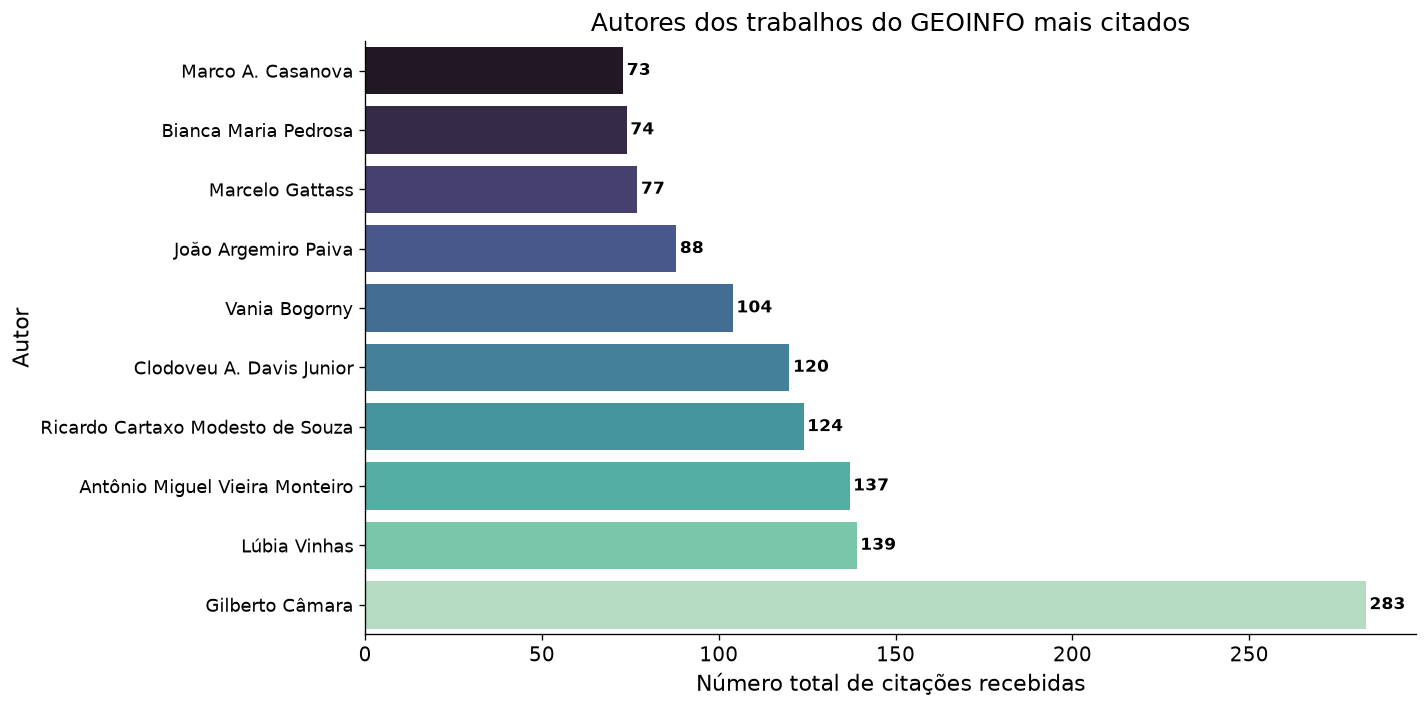

In [21]:
plt.figure(figsize=(12, 6))

COLORS = sns.color_palette("mako", len(top_autores))

ax = sns.barplot(
    x=top_autores.values, 
    y=top_autores.index, 
    palette=COLORS, 
    hue=top_autores.index,
    legend=False
)

ax.set_title("Autores dos trabalhos do GEOINFO mais citados", fontsize=15)
ax.set_xlabel("Número total de citações recebidas", fontsize=13)
ax.set_ylabel("Autor", fontsize=13)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)

for i, v in enumerate(top_autores.values):
    ax.text(v + 1, i, f"{int(v)}", va="center", fontsize=10, fontweight="bold")

sns.despine()

plt.tight_layout()
plt.show()

## Em quais países os trabalhos do GEOINFO são mais utilizados?

In [22]:
top_paises = (
    df_citacoes["pais_padronizado"]
    .dropna()
    .value_counts()
    .head(10)
    .sort_values() 
)

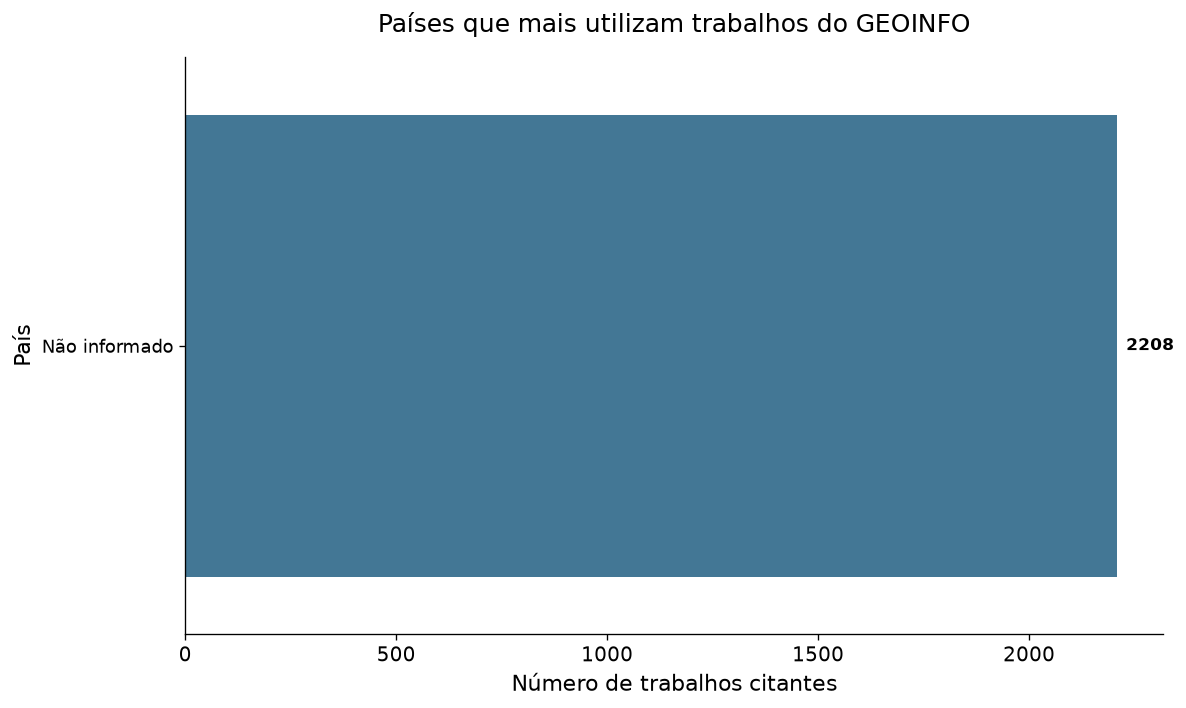

In [23]:
plt.figure(figsize=(10, 6))

COLORS = sns.color_palette("mako", len(top_paises))

ax = sns.barplot(
    x=top_paises.values, 
    y=top_paises.index, 
    palette=COLORS,
    hue=top_paises.index,
    legend=False
)

ax.set_title("Países que mais utilizam trabalhos do GEOINFO", fontsize=15, pad=15)
ax.set_xlabel("Número de trabalhos citantes", fontsize=13)
ax.set_ylabel("País", fontsize=13)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)

for i, v in enumerate(top_paises.values):
    ax.text(v + (max(top_paises.values) * 0.01), i, f"{int(v)}", va="center", fontsize=10, fontweight="bold")

sns.despine()

plt.tight_layout()
plt.show()

## Quais instituições mais citam trabalhos do GEOINFO?

In [24]:
df_citantes = pd.read_csv("../data/processed/trabalhos_citantes_final.csv")

top_instituicoes = (
    df_citantes["instituicoes"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)


top_instituicoes = (
    top_instituicoes[~top_instituicoes.isin(["", "Não informado"])]
    .value_counts()
    .head(10)       
    .sort_values()      
)

AttributeError: Can only use .str accessor with string values, not floating

In [25]:
plt.figure(figsize=(12, 6))

COLORS = sns.color_palette("mako", len(top_instituicoes))

ax = sns.barplot(
    x=top_instituicoes.values, 
    y=top_instituicoes.index, 
    palette=COLORS,
    hue=top_instituicoes.index,
    legend=False
)

ax.set_title("Instituições que mais citam trabalhos do GEOINFO", fontsize=15, pad=15)
ax.set_xlabel("Número de citações (Trabalhos citantes)", fontsize=13)
ax.set_ylabel("Instituição", fontsize=13)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)

for i, v in enumerate(top_instituicoes.values):
    ax.text(v + 0.1, i, f"{int(v)}", va="center", fontsize=10, fontweight="bold")

sns.despine()

plt.tight_layout()
plt.show()

NameError: name 'top_instituicoes' is not defined

<Figure size 1440x720 with 0 Axes>

## Em quais idiomas os trabalhos citantes foram publicados?

In [26]:
idiomas = (
    df_citacoes["idioma_padronizado"]
    .dropna()
)
idiomas = idiomas[~idiomas.isin(["Não informado"])].value_counts()

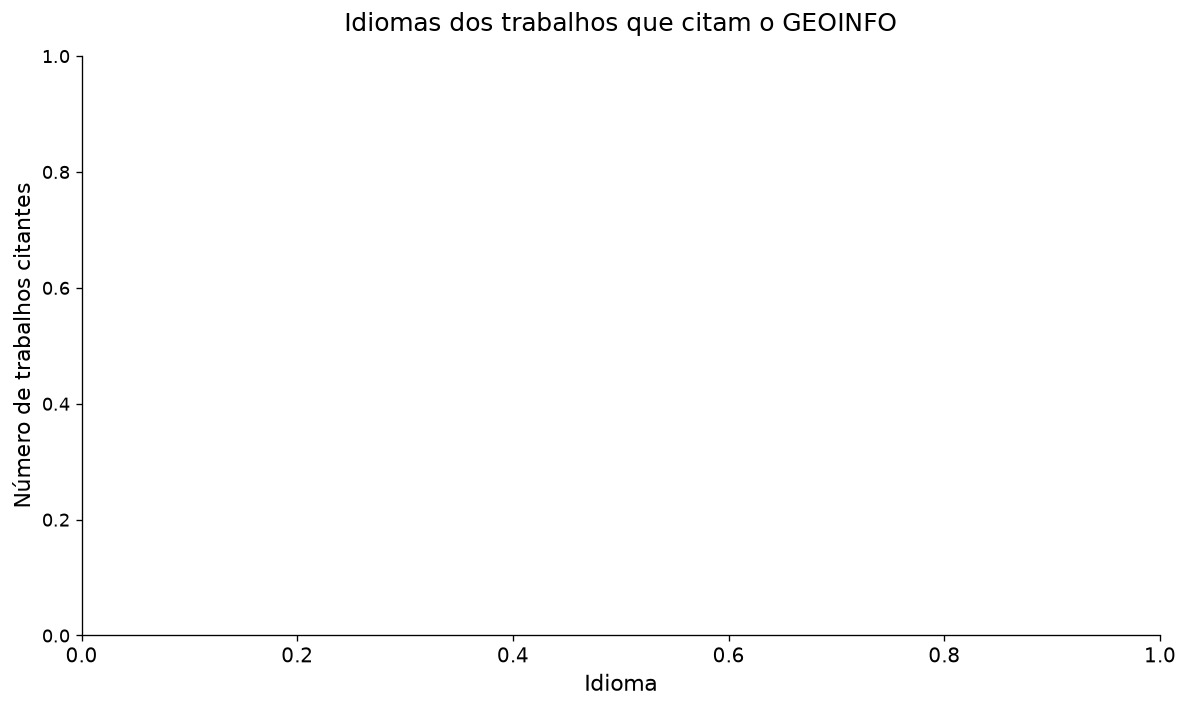

In [27]:
plt.figure(figsize=(10, 6))

COLORS = sns.color_palette("mako", len(idiomas))

ax = sns.barplot(
    x=idiomas.index, 
    y=idiomas.values, 
    palette=COLORS,
    hue=idiomas.index
)

# 4. Ajustes de títulos e eixos
ax.set_title("Idiomas dos trabalhos que citam o GEOINFO", fontsize=15, pad=15)
ax.set_xlabel("Idioma", fontsize=13)
ax.set_ylabel("Número de trabalhos citantes", fontsize=13)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)

if ax.get_legend() is not None:
    ax.get_legend().remove()

# 5. Adicionar o valor absoluto no topo de cada barra
for i, v in enumerate(idiomas.values):
    ax.text(i, v + (max(idiomas.values) * 0.015), f"{int(v)}", ha="center", va="bottom", fontsize=10, fontweight="bold")

sns.despine()

plt.tight_layout()
plt.show()

## Quais são os principais veículos que citam trabalhos do GEOINFO?

In [28]:
top_veiculos = (
    df_citacoes["veiculo_publicacao"]
    .dropna()
)

top_veiculos = (
    top_veiculos[~top_veiculos.isin(["Não informado"])]
    .value_counts()
    .head(10)
    .sort_values() 
)

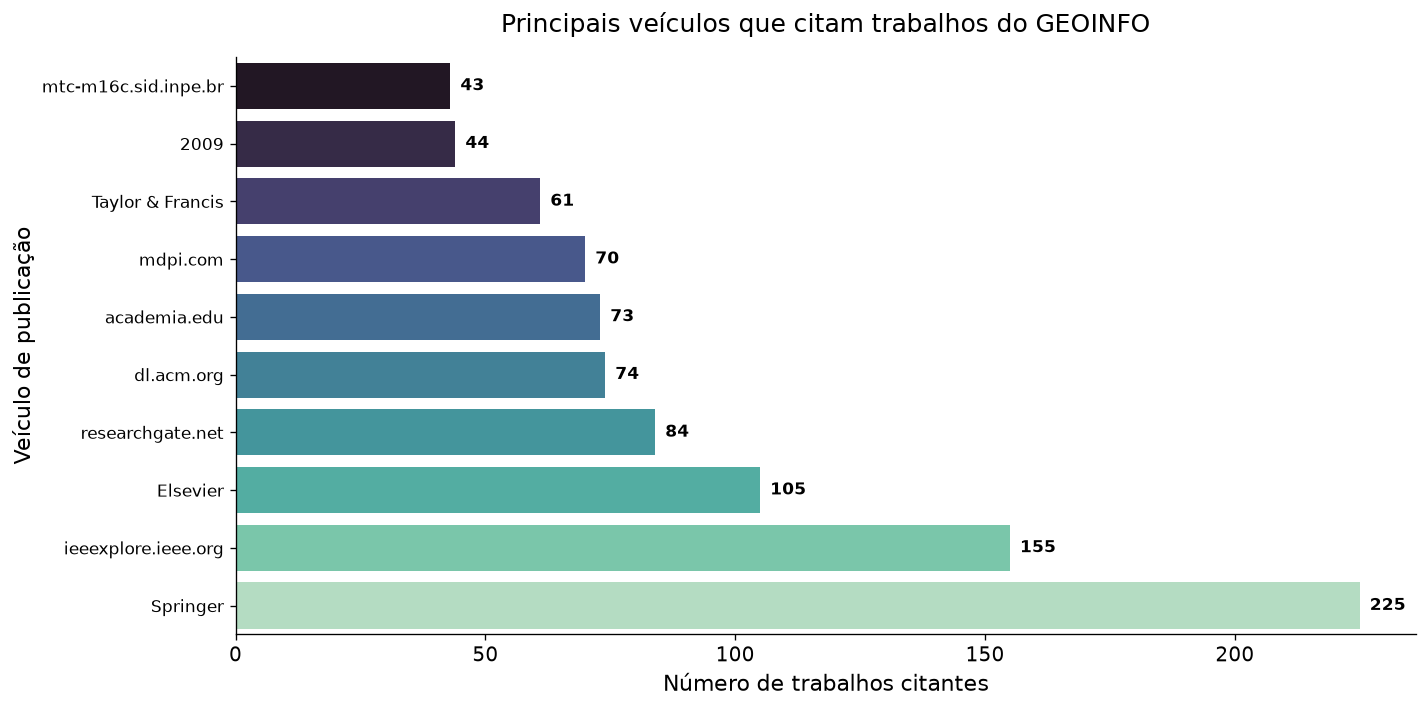

In [29]:
plt.figure(figsize=(12, 6))

COLORS = sns.color_palette("mako", len(top_veiculos))

ax = sns.barplot(
    x=top_veiculos.values, 
    y=top_veiculos.index, 
    palette=COLORS,
    hue=top_veiculos.index
)

ax.set_title("Principais veículos que citam trabalhos do GEOINFO", fontsize=15, pad=15)
ax.set_xlabel("Número de trabalhos citantes", fontsize=13)
ax.set_ylabel("Veículo de publicação", fontsize=13)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=10)

if ax.get_legend() is not None:
    ax.get_legend().remove()

for i, v in enumerate(top_veiculos.values):
    ax.text(v + 2, i, f"{int(v)}", va="center", fontsize=10, fontweight="bold")

sns.despine()

plt.tight_layout()
plt.show()

## Como evoluiu o número de citações ao longo dos anos?

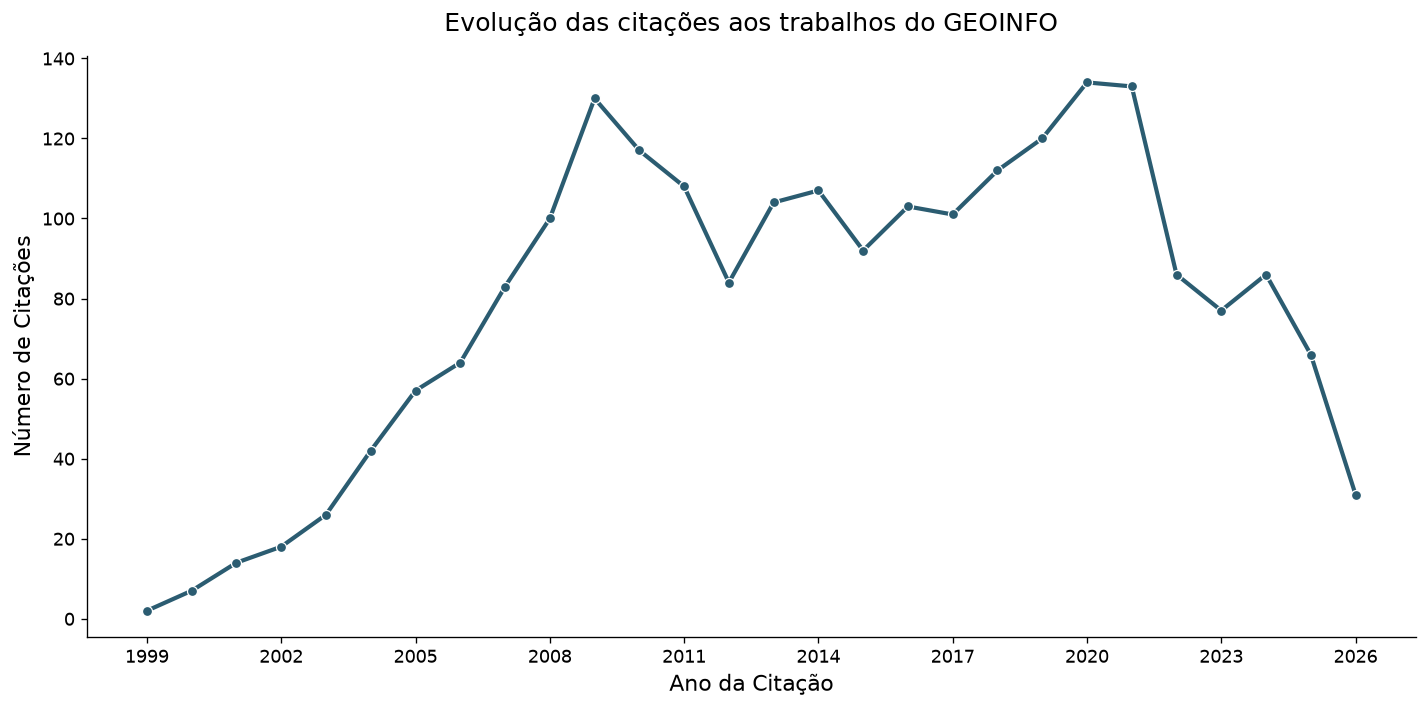

In [30]:
df_validas = df_citacoes[df_citacoes["ano"].between(1999, 2026)]

citacoes_ano = df_validas["ano"].value_counts().sort_index()

plt.figure(figsize=(12, 6))

COLOR_LINE = "#2b5c71"

ax = sns.lineplot(
    x=citacoes_ano.index, 
    y=citacoes_ano.values, 
    marker="o", 
    linewidth=2.5, 
    color=COLOR_LINE
)

ax.set_title("Evolução das citações aos trabalhos do GEOINFO", fontsize=15, pad=15)
ax.set_xlabel("Ano da Citação", fontsize=13)
ax.set_ylabel("Número de Citações", fontsize=13)

ax.set_xticks(range(1999, int(citacoes_ano.index.max()) + 1, 3))

ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

sns.despine()

plt.tight_layout()
plt.show()

## Quais áreas do conhecimento mais utilizam pesquisas publicadas no GEOINFO?

In [31]:
top_areas = (
    df_citacoes["dominio_tematico"]
    .dropna()
)

top_areas = (
    top_areas[~top_areas.isin(["Não informado"])]
    .value_counts()
    .head(10)
    .sort_values() 
)

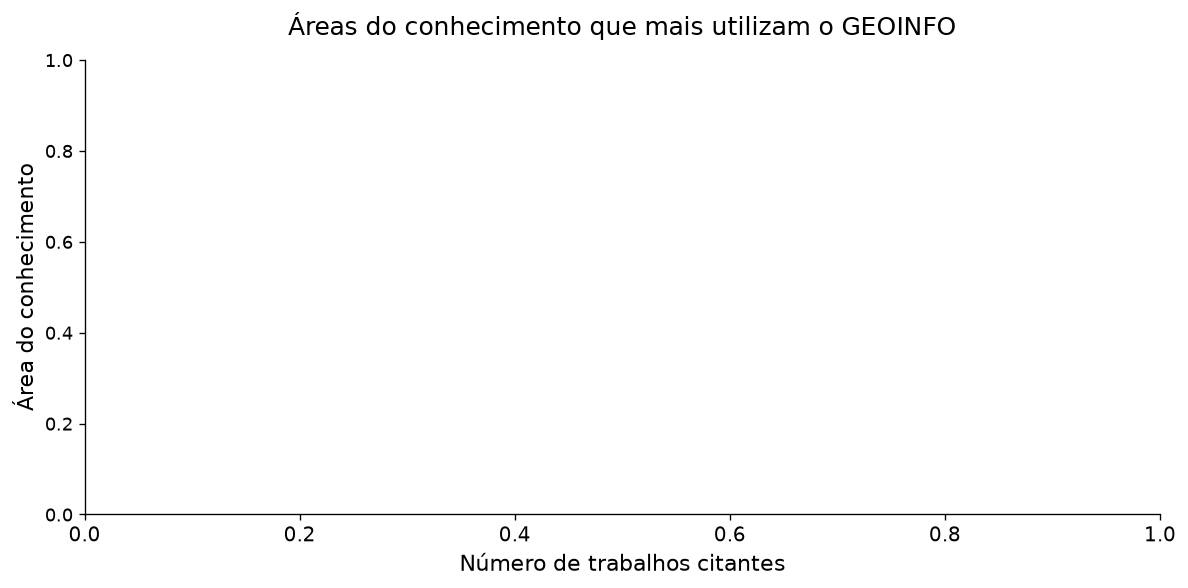

In [32]:
plt.figure(figsize=(10, 5))

COLORS = sns.color_palette("mako", len(top_areas))

ax = sns.barplot(
    x=top_areas.values, 
    y=top_areas.index, 
    palette=COLORS,
    hue=top_areas.index
)

# 4. Títulos e rótulos
ax.set_title("Áreas do conhecimento que mais utilizam o GEOINFO", fontsize=15, pad=15)
ax.set_xlabel("Número de trabalhos citantes", fontsize=13)
ax.set_ylabel("Área do conhecimento", fontsize=13)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)

if ax.get_legend() is not None:
    ax.get_legend().remove()

# 5. Adiciona os rótulos numéricos nas barras
for i, v in enumerate(top_areas.values):
    ax.text(v + 0.4, i, f"{int(v)}", va="center", fontsize=10, fontweight="bold")

sns.despine()

plt.tight_layout()
plt.show()

In [33]:
top_campos = (
    df_citacoes["campo"]
    .dropna()
)

top_campos = (
    top_campos[~top_campos.isin(["Não informado"])]
    .value_counts()
    .head(10)
    .sort_values() 
)

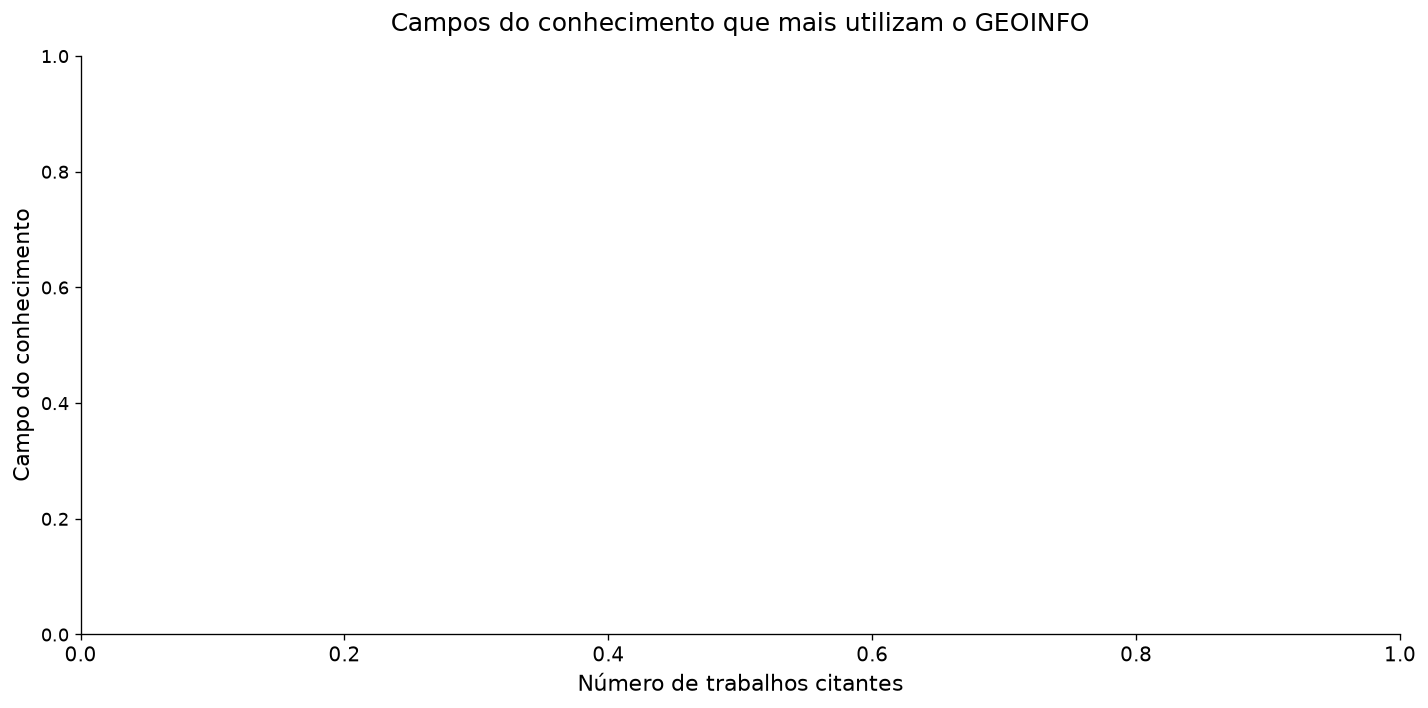

In [34]:
plt.figure(figsize=(12, 6))

COLORS = sns.color_palette("mako", len(top_campos))

ax = sns.barplot(
    x=top_campos.values, 
    y=top_campos.index, 
    palette=COLORS,
    hue=top_campos.index
)

ax.set_title("Campos do conhecimento que mais utilizam o GEOINFO", fontsize=15, pad=15)
ax.set_xlabel("Número de trabalhos citantes", fontsize=13)
ax.set_ylabel("Campo do conhecimento", fontsize=13)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)

if ax.get_legend() is not None:
    ax.get_legend().remove()

for i, v in enumerate(top_campos.values):
    ax.text(v + 0.2, i, f"{int(v)}", va="center", fontsize=10, fontweight="bold")

sns.despine()

plt.tight_layout()
plt.show()

In [35]:
top_subcampos = (
    df_citacoes["subcampo"]
    .dropna()
)

top_subcampos = (
    top_subcampos[~top_subcampos.isin(["Não informado"])]
    .value_counts()
    .head(10)
    .sort_values()
)

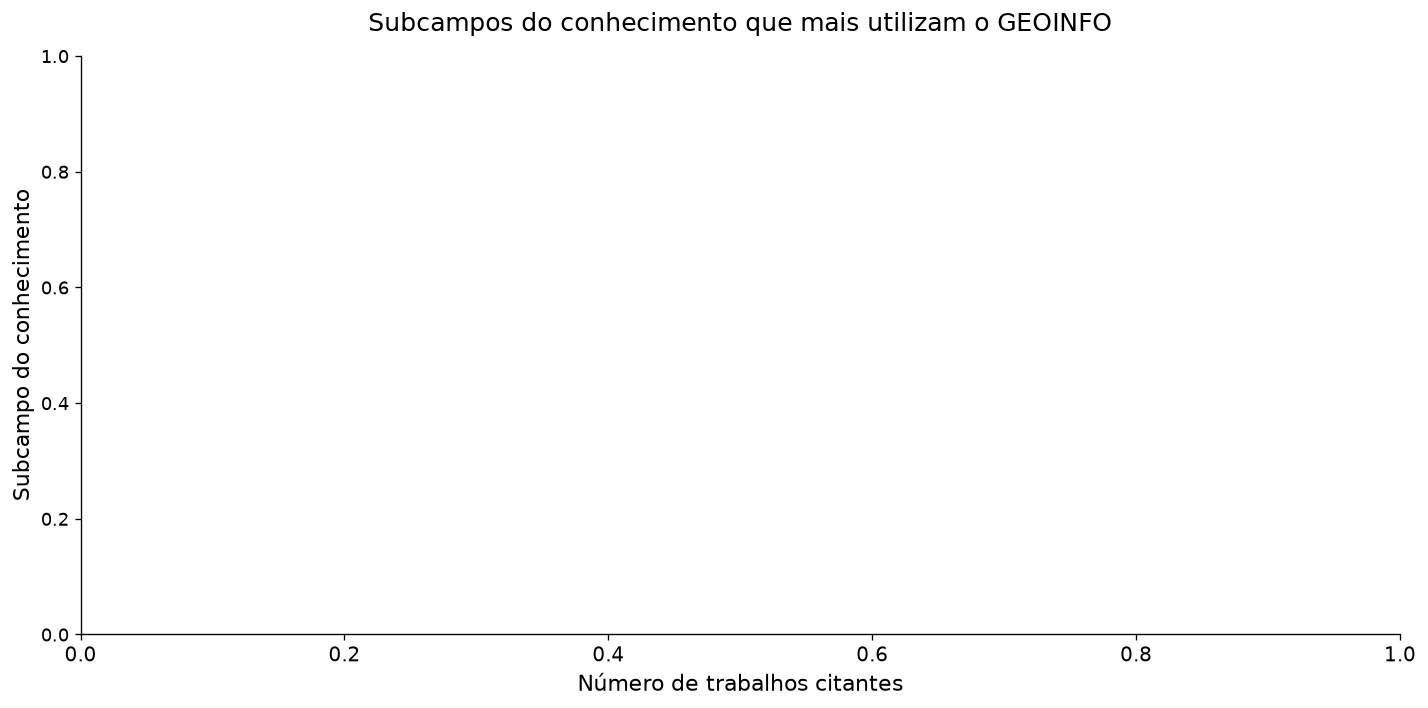

In [36]:
plt.figure(figsize=(12, 6))

COLORS = sns.color_palette("mako", len(top_subcampos))

ax = sns.barplot(
    x=top_subcampos.values, 
    y=top_subcampos.index, 
    palette=COLORS,
    hue=top_subcampos.index
)

ax.set_title("Subcampos do conhecimento que mais utilizam o GEOINFO", fontsize=15, pad=15)
ax.set_xlabel("Número de trabalhos citantes", fontsize=13)
ax.set_ylabel("Subcampo do conhecimento", fontsize=13)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)

if ax.get_legend() is not None:
    ax.get_legend().remove()

for i, v in enumerate(top_subcampos.values):
    ax.text(v + 0.1, i, f"{int(v)}", va="center", fontsize=10, fontweight="bold")

sns.despine()

plt.tight_layout()
plt.show()

# Comparação das bases

In [37]:
dados_indicadores = {
    "Indicador": [
        "Trabalhos GEOINFO",
        "Trabalhos Citantes",
        "Autores Citantes",
        "Anos Analisados",
        "Instituições (Origem)",
        "Instituições (Citante)",
        "Veículos de Publicação",
        "Países",
        "Tipos de Documento",
        "Áreas do Conhecimento",
        "Idiomas"
    ],
    "Quantidade": [
        df_geoinfo["identificador"].nunique(),
        df_citacoes["id_citante"].nunique(),
        df_citacoes["autores"].dropna().nunique(),
        df_citacoes["ano"].nunique(),
        df_autores_instituicoes["instituicao_padronizada"].dropna().nunique(),
        df_citacoes["instituicoes"].dropna().nunique(),
        df_citacoes["veiculo_publicacao"].dropna().nunique(),
        df_citacoes["pais_padronizado"].dropna().nunique(),
        df_citacoes["tipo_documento"].dropna().nunique(),
        df_citacoes["dominio_tematico"].dropna().nunique(),
        df_citacoes["idioma_padronizado"].dropna().nunique(),
    ],
    "Nível de Cobertura": [
        "Geral (Scholar)", "Geral (Scholar)", "Geral (Scholar)", "Geral (Scholar)",
        "Geral (Scholar)", "Geral (Scholar)", "Geral (Scholar)",
        "Enriquecido (OpenAlex)", "Enriquecido (OpenAlex)", "Enriquecido (OpenAlex)",
        "Enriquecido (OpenAlex)"
    ]
}

df_indicadores = pd.DataFrame(dados_indicadores)

print("--- TABELA DOS INDICADORES CONSOLIDADA ---")
print(df_indicadores.to_string(index=False))

--- TABELA DOS INDICADORES CONSOLIDADA ---
             Indicador  Quantidade     Nível de Cobertura
     Trabalhos GEOINFO         681        Geral (Scholar)
    Trabalhos Citantes        2208        Geral (Scholar)
      Autores Citantes        2174        Geral (Scholar)
       Anos Analisados          32        Geral (Scholar)
 Instituições (Origem)         327        Geral (Scholar)
Instituições (Citante)           0        Geral (Scholar)
Veículos de Publicação         312        Geral (Scholar)
                Países           1 Enriquecido (OpenAlex)
    Tipos de Documento           0 Enriquecido (OpenAlex)
 Áreas do Conhecimento           0 Enriquecido (OpenAlex)
               Idiomas           1 Enriquecido (OpenAlex)


               Categoria  Total de Citações  Percentual (%)
0  Apenas Google Scholar               2208           100.0
1      Em Ambas as Bases                  0             0.0
2        Apenas OpenAlex                  0             0.0


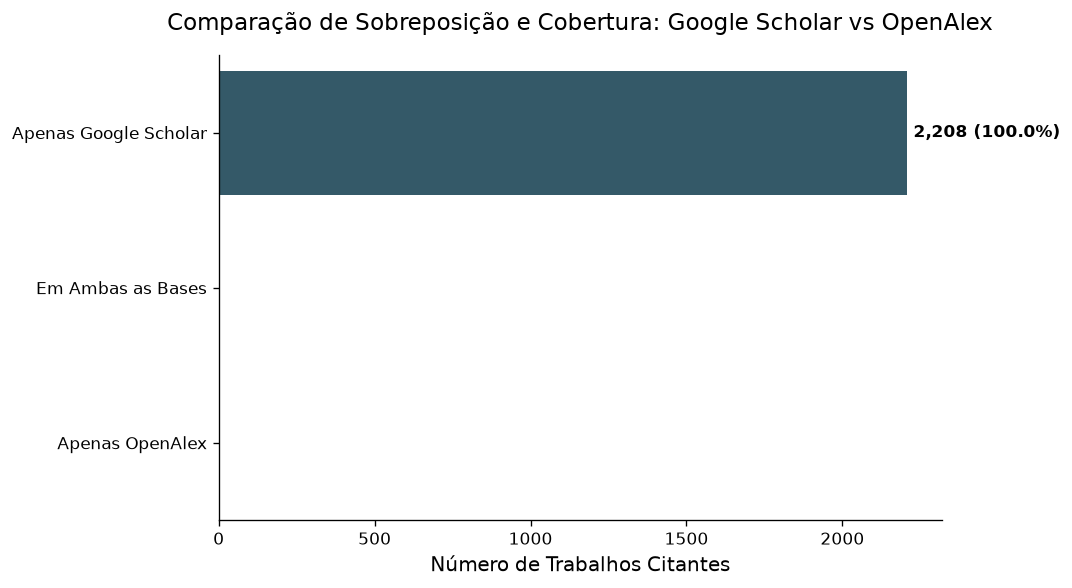

In [38]:
distribuicao_fontes = df_citacoes["fonte_dados"].value_counts()

df_sobreposicao = pd.DataFrame({
    "Categoria": [
        "Apenas Google Scholar",
        "Em Ambas as Bases",
        "Apenas OpenAlex"
    ],
    "Total de Citações": [
        distribuicao_fontes.get("Google Scholar", 0),
        distribuicao_fontes.get("Google Scholar; OpenAlex", 0),
        distribuicao_fontes.get("OpenAlex", 0),
    ]
})

df_sobreposicao["Percentual (%)"] = (df_sobreposicao["Total de Citações"] / len(df_citacoes)) * 100

print(df_sobreposicao)

plt.figure(figsize=(9, 5))

COLORS = ["#2b5c71", "#2e7d32", "#d9534f"]

ax = sns.barplot(
    data=df_sobreposicao,
    x="Total de Citações",
    y="Categoria",
    palette=COLORS,
    hue="Categoria"
)

ax.set_title("Comparação de Sobreposição e Cobertura: Google Scholar vs OpenAlex", fontsize=14, pad=15)
ax.set_xlabel("Número de Trabalhos Citantes", fontsize=12)
ax.set_ylabel("", fontsize=12)

for p, pct in zip(ax.patches, df_sobreposicao["Percentual (%)"]):
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{int(width):,} ({pct:.1f}%)",
            (width + 20, p.get_y() + p.get_height() / 2),
            ha='left', va='center',
            fontsize=10, fontweight='bold'
        )

sns.despine()
plt.tight_layout()
plt.show()

# Referências